---
title: "Grouped data: TabPFN 3 vs 3.5 vs XGBoost"
description: "Compare models on mice protein measurements, using grouped splits to evaluate predictions for unseen animals."
cookbookTags:
  - classification
  - grouped data
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

## What is grouped data?

**Grouped data** has several rows from the same source, such as repeated
visits from one patient or measurements from one mouse. These rows are
related: 15 measurements from one mouse are not the same as 15 different mice.

To test predictions for **new mice**, keep each mouse's measurements together:
use them all for training or all for testing. Mixing them across both can
make the model look better than it is at predicting new animals.

## The problem: predict a mouse's experimental class

The [Mice Protein Expression dataset](https://doi.org/10.24432/C50S3Z) contains
protein measurements from **72 mice**, with 15 rows per mouse. We predict
which of eight experimental classes each mouse belongs to. Although these
labels are already known, predicting them tests whether the proteins reveal
patterns linked to learning and treatment in a mouse model of Down syndrome.

The classes combine mouse type, a learning task or comparison condition,
and treatment with saline or the drug memantine. Trisomy mice model Down
syndrome; `CS` denotes the learning task and `SC` the comparison condition.

| Class label | Mouse type | Condition | Treatment |
| --- | --- | --- | --- |
| `c-CS-s` | Control | Learning task | Saline |
| `c-CS-m` | Control | Learning task | Memantine |
| `c-SC-s` | Control | Comparison | Saline |
| `c-SC-m` | Control | Comparison | Memantine |
| `t-CS-s` | Trisomy | Learning task | Saline |
| `t-CS-m` | Trisomy | Learning task | Memantine |
| `t-SC-s` | Trisomy | Comparison | Saline |
| `t-SC-m` | Trisomy | Comparison | Memantine |

We compare **TabPFN 3, TabPFN 3.5, and XGBoost** on the same held-out mice,
then try Thinking mode. Each mouse is a group; several mice share a class.

## Setup

Install the pinned client and dependencies. TabPFN runs through the API; XGBoost
runs on CPU. Authenticate with your usual TabPFN
client setup before running the comparison.

In [ ]:
%pip install -q --upgrade tabpfn-client==0.6.0 pandas==2.3.3 numpy==2.5.3 scikit-learn==1.9.0 xgboost==3.4.1 matplotlib==3.11.2 pyarrow==25.0.1 huggingface-hub==1.31.0

In [2]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from IPython.display import display
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from xgboost import XGBClassifier

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

## Load the curated dataset and its splits

The [Beyond Arena collection](https://huggingface.co/datasets/TabArena/BeyondArena)
includes the data and explicit train/test row indices. Pinning the collection
revision makes these splits reproducible.

The mice task is `1273313252` (`mice_protein_trisomy_discriminant`), derived from
[UCI Mice Protein Expression](https://doi.org/10.24432/C50S3Z), licensed CC BY 4.0.
The curation removes the three columns that directly define the target and
reduces `MouseID` to the actual animal identifier. This lets the split keep
all measurements from the same animal together.

In [3]:
def load_task(name, version):
    def download(filename):
        return hf_hub_download(
            "TabArena/BeyondArena", f"{name}/{version}/{filename}",
            repo_type="dataset", revision="88059a3f02ec4abb6ec24bbe0d1c0b7eed31485d",
        )
    frame = pd.read_parquet(download("dataset.parquet"))
    splits = json.loads(Path(download(
        "experiment_metadata.predictive-ml-splits-mold-v1.json"
    )).read_text())["splits"]
    return frame, splits

mice, mice_splits = load_task(
    "mice_protein_trisomy_discriminant", "019d738d-99a8-7850-b911-f244ac4ad485"
)
print(f"Mice: {len(mice):,} measurements from {mice.MouseID.nunique()} animals")

Mice: 1,080 measurements from 72 animals


## Check that the split matches deployment

Use the three folds of the first grouped repetition. Each fold trains on
48 mice (720 measurements) and tests on 24 other mice (360 measurements).
The assertions below check that neither row indices nor mouse identifiers
overlap between training and test data.

This evaluation asks how well the model predicts experimental classes for
**new animals**. If the intended use were another measurement from an animal
already seen during training, that would call for a different evaluation.
Choose the group at the level where generalization matters; for example,
holding out patients answers a different question from holding out hospitals.

In [4]:
splits = {
    "Mice proteins": [mice_splits["0"][str(fold)] for fold in range(3)],
}
split_rows = []
for fold, (train, test) in enumerate(splits["Mice proteins"]):
    assert not set(train) & set(test)
    assert not set(mice.iloc[train].MouseID) & set(mice.iloc[test].MouseID)
    split_rows.append({"Dataset": "Mice proteins", "Split": fold,
                       "Train rows": len(train), "Test rows": len(test),
                       "Train groups": mice.iloc[train].MouseID.nunique(),
                       "Test groups": mice.iloc[test].MouseID.nunique()})
split_summary = pd.DataFrame(split_rows)
display(split_summary)

,Dataset,Split,Train rows,Test rows,Train groups,Test groups
0,Mice proteins,0,720,360,48,24
1,Mice proteins,1,720,360,48,24
2,Mice proteins,2,720,360,48,24


## Compare the three models

Use protein measurements as predictors and omit `MouseID`. Thinking receives
the original group column below to guide its internal validation. Preserve
missing values and encode categorical columns with levels learned from the
training rows; unseen test categories become missing for every model.

Both TabPFN versions keep their default estimator count and random state.
XGBoost uses a fixed CPU histogram configuration: 500 trees, depth 4, and a
learning rate of 0.05. There is no test-set tuning or class resampling.

Use **multiclass log-loss** (lower is better), matching the selected Thinking
objective. It scores the probability assigned to the correct class and
penalizes confident mistakes more strongly. This comparison uses simple
preprocessing, rather than reproducing the collection's tuned baselines.

In [6]:
def prepare(frame, target, split_column, train, test):
    X_train = frame.iloc[train].drop(columns=[target, split_column]).copy()
    X_test = frame.iloc[test].drop(columns=[target, split_column]).copy()
    for column in X_train.select_dtypes(include=["category", "object", "string"]):
        categories = pd.Index(X_train[column].dropna().unique())
        X_train[column] = pd.Categorical(X_train[column], categories=categories)
        X_test[column] = pd.Categorical(X_test[column], categories=categories)
    encoder = LabelEncoder().fit(frame.iloc[train][target])
    return (X_train, X_test, encoder.transform(frame.iloc[train][target]),
            encoder.transform(frame.iloc[test][target]))

def compare(frame, target, split_column, task_splits, name, *,
            thinking_effort=None, thinking_metric=None, group_col=None):
    rows, predictions = [], {}
    for fold, (train, test) in enumerate(task_splits):
        X_train, X_test, y_train, y_test = prepare(frame, target, split_column, train, test)
        categorical = [X_train.columns.get_loc(c) for c in X_train.select_dtypes("category")]
        if thinking_effort is not None and group_col is not None:
            # Keep the original mouse identifiers for Thinking's grouped validation.
            X_train[group_col] = frame.iloc[train][group_col]
            X_test[group_col] = frame.iloc[test][group_col]
        for model_name, version in [("TabPFN 3", ModelVersion.V3),
                                    ("TabPFN 3.5", ModelVersion.V3_5),
                                    ("XGBoost", None)]:
            if thinking_effort is not None and version is None:
                continue
            thinking = {}
            if thinking_effort is not None:
                model_name += " Thinking (high)"
                thinking = dict(thinking_effort=thinking_effort, thinking_metric=thinking_metric,
                                group_col=group_col)
            model = (XGBClassifier(
                n_estimators=500, max_depth=4, learning_rate=0.05,
                tree_method="hist", device="cpu", enable_categorical=True,
                n_jobs=8, random_state=42,
            ) if version is None else TabPFNClassifier.create_default_for_version(
                version,
                categorical_features_indices=categorical, **thinking,
            ))
            started = time.perf_counter()
            model.fit(X_train, y_train)
            prediction = model.predict_proba(X_test)
            seconds = time.perf_counter() - started
            assert np.isfinite(prediction).all()
            assert np.allclose(prediction.sum(axis=1), 1, atol=1e-5)
            assert np.array_equal(model.classes_, np.arange(len(np.unique(y_train))))
            rows.append({"Dataset": name, "Split": fold, "Model": model_name,
                         "Log-loss": log_loss(y_test, prediction),
                         "Seconds": seconds})
            predictions[f"{fold}_{model_name}"] = prediction
            predictions[f"{fold}_y_test"] = y_test
            print(f"{name}, split {fold}: {model_name} finished in {seconds:.1f}s", flush=True)
    return pd.DataFrame(rows), predictions

### Unseen mice

Each test fold contains 24 animals, with 15 measurements per animal. Log-loss
is averaged over measurements; because each animal has the same number of
measurements, each animal has equal weight. The three folds are the evaluation
units, not 1,080 independent animals.

In [7]:
mice_results, mice_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins"
)
display(mice_results[["Dataset", "Split", "Model", "Log-loss"]].round(4))

Mice proteins, split 0: restored TabPFN 3


Mice proteins, split 0: restored TabPFN 3.5


Mice proteins, split 0: restored XGBoost


Mice proteins, split 1: restored TabPFN 3


Mice proteins, split 1: restored TabPFN 3.5


Mice proteins, split 1: restored XGBoost


Mice proteins, split 2: restored TabPFN 3


Mice proteins, split 2: restored TabPFN 3.5


Mice proteins, split 2: restored XGBoost


,Dataset,Split,Model,Log-loss
0,Mice proteins,0,TabPFN 3,1.0772
1,Mice proteins,0,TabPFN 3.5,0.7729
2,Mice proteins,0,XGBoost,1.7709
3,Mice proteins,1,TabPFN 3,1.1772
4,Mice proteins,1,TabPFN 3.5,0.6991
5,Mice proteins,1,XGBoost,2.3423
6,Mice proteins,2,TabPFN 3,1.1296
7,Mice proteins,2,TabPFN 3.5,0.7970
8,Mice proteins,2,XGBoost,1.6562


## Performance on grouped data

The table shows mean log-loss across the three grouped splits. Lower is
better. Keep the individual fold scores above in view: the held-out mice
change between folds, so performance varies with which animals are unseen.

In [9]:
all_results = mice_results.copy()
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Seconds"]
].mean()
print("Mice proteins: Log-loss")
display(summary.loc["Mice proteins", ["Log-loss"]].round(4))

Mice proteins: Log-loss


,Log-loss
Model,
TabPFN 3,1.1280
TabPFN 3.5,0.7563
XGBoost,1.9231


## Try high-effort Thinking

[Thinking mode](https://github.com/PriorLabs/tabpfn-client#thinking-mode) spends
more computation during `fit()` searching model configurations. Set
`thinking_effort="high"` and choose `thinking_metric="log_loss"` before
fitting. Use `predict_proba()` to evaluate the resulting probabilities.

Run the same splits with the same training rows and preprocessing. Only
training labels are passed to `fit()`; held-out labels are used for scoring.
Pass `group_col="MouseID"` to keep animals together in Thinking's internal
validation, preserving the original identifiers in both training and test
frames. Standard models omit this column.

There are two places to respect groups: the **outer split** measures
performance on unseen mice, while **internal validation** helps Thinking
choose a configuration using only the training mice. Setting `group_col`
does not replace the outer split; both must keep each animal's measurements
together.

In [10]:
mice_thinking, mice_thinking_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins",
    thinking_effort="high", thinking_metric="log_loss", group_col="MouseID",
)

Mice proteins, split 0: restored TabPFN 3 Thinking (high)


Mice proteins, split 0: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 1: restored TabPFN 3 Thinking (high)


Mice proteins, split 1: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 2: restored TabPFN 3 Thinking (high)


Mice proteins, split 2: restored TabPFN 3.5 Thinking (high)


### Does Thinking improve held-out performance?

Compare each version with its standard counterpart using log-loss. Bars
show the three-split mean and dots show individual splits; the dots are
descriptive, not confidence intervals. XGBoost remains the fixed CPU baseline.

Mice proteins: Log-loss (lower is better)


,Log-loss
Model,
TabPFN 3,1.1280
TabPFN 3 Thinking (high),1.0963
TabPFN 3.5,0.7563
TabPFN 3.5 Thinking (high),0.7339
XGBoost,1.9231


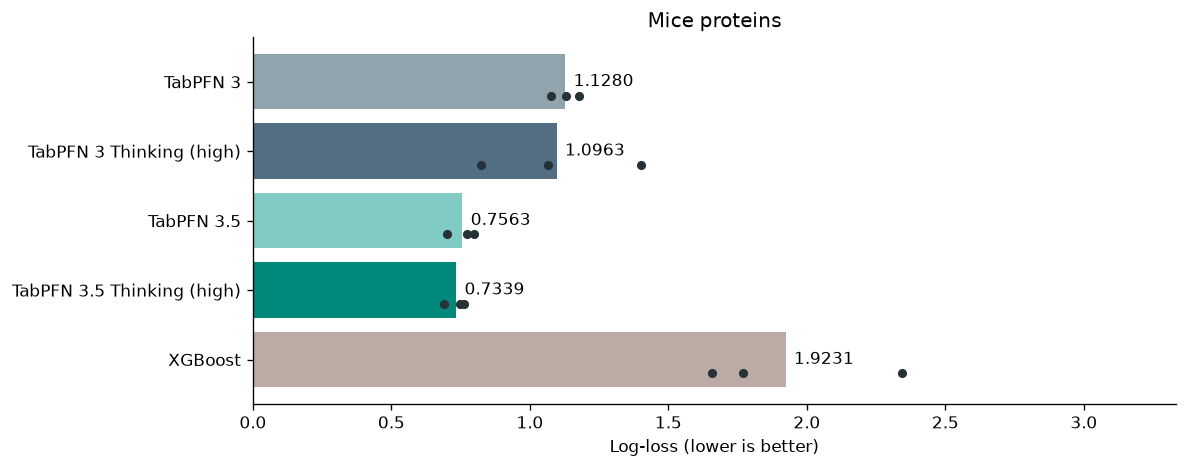

In [11]:
all_results = pd.concat([all_results, mice_thinking], ignore_index=True)
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Seconds"]
].mean()
model_order = ["TabPFN 3", "TabPFN 3 Thinking (high)",
               "TabPFN 3.5", "TabPFN 3.5 Thinking (high)", "XGBoost"]
dataset, metric, direction = "Mice proteins", "Log-loss", "lower"
print(f"{dataset}: {metric} ({direction} is better)")
display(summary.loc[dataset, [metric]].reindex(model_order).round(4))
scores = all_results[all_results.Dataset == dataset].pivot(
    index="Model", columns="Split", values=metric
).reindex(model_order)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(scores.index, scores.mean(axis=1),
               color=["#90a4ae", "#536d83", "#80cbc4", "#00897b", "#bcaaa4"])
ax.bar_label(bars, fmt="%.4f", padding=5)
for position, (_, values) in enumerate(scores.iterrows()):
    ax.scatter(values, np.full(len(values), position + 0.20),
               color="#263238", s=20, zorder=3)
low, high = scores.to_numpy().min(), scores.to_numpy().max()
zoomed = low > 0 and high - low < 0.2 * high
padding = max((high - low) * 0.3, high * 0.015, 0.001)
ax.set_xlim(max(0, low - padding) if zoomed else 0, high + 2 * padding)
ax.set_title(dataset + ("\nZoomed axis (does not start at zero)" if zoomed else ""))
ax.set_xlabel(f"{metric} ({direction} is better)")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Reading the comparison

Mean log-loss is **1.1280** for TabPFN 3, **0.7563** for TabPFN 3.5, and
**1.9231** for XGBoost (lower is better). TabPFN 3.5 assigns better
probabilities to the correct experimental classes on these held-out mice.

TabPFN 3 Thinking improves mean log-loss from **1.1280 to 1.0963**, improving
2 of the three splits. TabPFN 3.5 Thinking improves it from
**0.7563 to 0.7339**, improving all three splits.

Keep the split fixed across models and inspect individual fold scores
alongside their mean. These scores describe predictions for unseen mice;
the 1,080 measurements should not be treated as 1,080 independent animals.